# Fine-tune `microsoft/trocr-base-handwritten` — train / validate / test

Fine-tunes the base TrOCR handwritten model on our line-crop transcriptions, using the same
three-way split as the zero-shot notebook:

| Split | Source | Role |
|-------|--------|------|
| **train** | every page except the last of each book | trains the model |
| **val** | the **last page of each book** | early stopping & best-checkpoint selection |
| **test** | the dedicated `test_set_line_crops/` folder | final, unbiased scoring |

Training uses `Seq2SeqTrainer` with `predict_with_generate=True`. Each epoch it scores **val CER**;
`load_best_model_at_end=True` + `EarlyStoppingCallback` keep the lowest-val-CER checkpoint and stop
once it stops improving. The model **never sees val or test** during training. After training we
score the **test set** once.

**Run on a Colab GPU runtime** (Runtime → Change runtime type → **L4 GPU**). Fine-tuning needs the
GPU; on CPU it is impractically slow.

In [3]:
# Colab has torch + transformers; evaluate/jiwer are needed for CER/WER.
!pip -q install evaluate jiwer

In [4]:
import os
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import evaluate

from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (TrOCRProcessor, VisionEncoderDecoderModel, default_data_collator,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback)

plt.rcParams["figure.figsize"] = (12, 4)

# Mount Drive
Upload the `transcriptions/` folder (with `test_set_line_crops/` inside it) to Drive, then point
`TRANSCRIPTIONS_DIR` at it below.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_TYPE = device.type
print(f"Using device: {device}  (type: {DEVICE_TYPE})")
if DEVICE_TYPE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — fine-tuning will be impractically slow; select an L4 GPU runtime.")

Using device: cuda  (type: cuda)
GPU: NVIDIA L4


# Config

In [7]:
# --- Model ---
BASE_MODEL = "microsoft/trocr-base-handwritten"

# --- Data (uploaded to Drive; adjust if your path differs) ---
TRANSCRIPTIONS_DIR = "/content/drive/MyDrive/transcriptions"
TEST_DIRNAME       = "test_set_line_crops"   # held-out test folder inside TRANSCRIPTIONS_DIR
TEST_SET_DIR       = os.path.join(TRANSCRIPTIONS_DIR, TEST_DIRNAME)

# --- Outputs ---
OUTPUT_DIR    = "/content/drive/MyDrive/transcriptions_splits/trocr_finetune"   # checkpoints
BEST_MODEL_DIR = "/content/drive/MyDrive/transcriptions_splits/trocr_best"      # final best model
SPLIT_OUT_DIR = "/content/drive/MyDrive/transcriptions_splits"                  # split CSVs

# --- Hyperparameters ---
MAX_TARGET_LENGTH   = 128
TRAIN_BATCH_SIZE    = 8
EVAL_BATCH_SIZE     = 8
LEARNING_RATE       = 5e-5
NUM_EPOCHS          = 20         # upper bound; early stopping usually stops sooner
EARLY_STOP_PATIENCE = 3          # stop if val CER does not improve for this many evals
NUM_BEAMS           = 4

print("Model    :", BASE_MODEL)
print("Data     :", TRANSCRIPTIONS_DIR)
print("Test set :", TEST_SET_DIR)
assert os.path.isdir(TRANSCRIPTIONS_DIR), f'Not found: {TRANSCRIPTIONS_DIR} — check the Drive path'
assert os.path.isdir(TEST_SET_DIR), f'Not found: {TEST_SET_DIR} — check the Drive path'

Model    : microsoft/trocr-base-handwritten
Data     : /content/drive/MyDrive/transcriptions
Test set : /content/drive/MyDrive/transcriptions/test_set_line_crops


# Build the train / val / test split

Identical rule to the zero-shot notebook: the **train+val pool** is everything under
`transcriptions/` except `test_set_line_crops/`; within it the **last (max) page of each book is the
validation set**, the rest is train. The **test set** is read from `test_set_line_crops/`.

In [8]:
def build_rows(jpg_list):
    """Pair each .jpg with its .txt; parse book + page from the file name."""
    rows, unmatched = [], []
    for p in jpg_list:
        m = re.match(r'B(\d)_P_?(\d+)', os.path.basename(p))
        if not m:
            unmatched.append(os.path.basename(p))
            continue
        txt = p[:-4] + '.txt'
        if not os.path.exists(txt):
            continue
        with open(txt, encoding='utf-8') as f:
            text = f.read().strip()
        if not text:
            continue
        rows.append({'file_name': p, 'text': text,
                     'book': 'B' + m.group(1), 'page': int(m.group(2))})
    return rows, unmatched

all_jpg      = sorted(glob(os.path.join(TRANSCRIPTIONS_DIR, '**', '*.jpg'), recursive=True))
trainval_jpg = [p for p in all_jpg if TEST_DIRNAME not in p.split(os.sep)]
test_jpg     = sorted(glob(os.path.join(TEST_SET_DIR, '**', '*.jpg'), recursive=True))

tv_rows, tv_unm = build_rows(trainval_jpg)
te_rows, te_unm = build_rows(test_jpg)
for label, unm in [('train/val', tv_unm), ('test', te_unm)]:
    if unm:
        print(f'WARNING: {len(unm)} {label} files did not match the book/page pattern, e.g. {unm[:5]}')

tv = pd.DataFrame(tv_rows)
val_page = tv.groupby('book')['page'].max().to_dict()
tv['split'] = tv.apply(lambda r: 'val' if r['page'] == val_page[r['book']] else 'train', axis=1)

train_df = tv[tv['split'] == 'train'].reset_index(drop=True)
val_df   = tv[tv['split'] == 'val'].reset_index(drop=True)
test_df  = pd.DataFrame(te_rows)
test_df['split'] = 'test'
test_df = test_df.reset_index(drop=True)

print('Validation (last) page per book:', val_page)
print('lines  ->  train:', len(train_df), ' val:', len(val_df), ' test:', len(test_df))
print()
print(pd.concat([train_df, val_df, test_df]).groupby(['book', 'split']).size().unstack(fill_value=0))

os.makedirs(SPLIT_OUT_DIR, exist_ok=True)
train_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(SPLIT_OUT_DIR, 'test.csv'), index=False)

Validation (last) page per book: {'B1': 231, 'B2': 224, 'B3': 276, 'B4': 282, 'B5': 20, 'B6': 20}
lines  ->  train: 726  val: 194  test: 189

split  test  train  val
book                   
B1       24     98   30
B2       30    112   30
B3       32    129   29
B4       28    115   30
B5       39    137   38
B6       36    135   37


# Dataset & processor

Light augmentation on **train** (small affine jitter) to regularise; clean grayscale for **val/test**
so evaluation is deterministic.

In [9]:
class LineOCRDataset(Dataset):
    def __init__(self, df, processor, transforms=None, max_target_length=128):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transforms = transforms
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df['file_name'][idx]).convert('RGB')
        if self.transforms:
            image = self.transforms(image)
        pixel_values = self.processor(image, return_tensors='pt').pixel_values
        labels = self.processor.tokenizer(
            self.df['text'][idx],
            padding='max_length',
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]
        return {'pixel_values': pixel_values.squeeze(), 'labels': torch.tensor(labels)}

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=2, translate=(0.01, 0.02), scale=(0.95, 1.05), shear=2,
                            fill=255),
])
eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
])

processor = TrOCRProcessor.from_pretrained(BASE_MODEL)
train_ds  = LineOCRDataset(train_df, processor, train_transforms, MAX_TARGET_LENGTH)
val_ds    = LineOCRDataset(val_df,   processor, eval_transforms,  MAX_TARGET_LENGTH)
test_ds   = LineOCRDataset(test_df,  processor, eval_transforms,  MAX_TARGET_LENGTH)
print('datasets ->  train:', len(train_ds), ' val:', len(val_ds), ' test:', len(test_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

datasets ->  train: 726  val: 194  test: 189


# Model & metrics

In [10]:
model = VisionEncoderDecoderModel.from_pretrained(BASE_MODEL)

# Tie special tokens / vocab to the processor and set generation defaults.
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.generation_config.max_length  = MAX_TARGET_LENGTH
model.generation_config.num_beams   = NUM_BEAMS
model.to(device)

cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str  = processor.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.batch_decode(label_ids, skip_special_tokens=True)
    return {'cer': cer_metric.compute(predictions=pred_str, references=label_str),
            'wer': wer_metric.compute(predictions=pred_str, references=label_str)}

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# Train with validation-based early stopping

- `eval_strategy='epoch'` + `save_strategy='epoch'` — evaluate & checkpoint each epoch,
- `metric_for_best_model='cer'`, `greater_is_better=False` — lower val CER is better,
- `load_best_model_at_end=True` — restore the best checkpoint when training ends,
- `EarlyStoppingCallback(patience=EARLY_STOP_PATIENCE)` — stop when val CER plateaus.

In [11]:
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    predict_with_generate=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    num_train_epochs=NUM_EPOCHS,
    fp16=(DEVICE_TYPE == 'cuda'),
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='cer',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
    seed=42,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,                 # validation set drives early stopping
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
)

In [12]:
train_result = trainer.train()
print('Training done. Best val CER checkpoint restored (load_best_model_at_end=True).')
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best val CER  :', trainer.state.best_metric)

Epoch,Training Loss,Validation Loss,Cer,Wer
1,3.933136,3.385957,0.451274,0.733131
2,1.411342,1.977923,0.204565,0.362310
3,0.936050,1.590350,0.183673,0.345897
4,0.704970,1.439272,0.182224,0.350760
5,0.599201,1.696547,0.183673,0.358663
6,0.773031,1.493657,0.188504,0.356231
7,0.458345,1.423113,0.165439,0.316717
8,0.329056,1.583244,0.188745,0.347112
9,0.275526,1.450888,0.158435,0.305775
10,0.244076,1.562476,0.188142,0.339818


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.layers.0.attention.q_proj.weight', 'encoder.layers.0.attention.k_proj.weight', 'encoder.layers.0.attention.v_proj.weight', 'encoder.layers.0.attention.o_proj.weight', 'encoder.layers.0.attention.o_proj.bias', 'encoder.layers.0.layernorm_before.weight', 'encoder.layers.0.layernorm_before.bias', 'encoder.layers.0.layernorm_after.weight', 'encoder.layers.0.layernorm_after.bias', 'encoder.layers.0.mlp.fc1.weight', 'encoder.layers.0.mlp.fc1.bias', 'encoder.layers.0.mlp.fc2.weight', 'encoder.layers.0.mlp.fc2.bias', 'encoder.layers.1.attention.q_proj.weight', 'encoder.layers.1.attention.k_proj.weight', 'encoder.layers.1.attention.v_proj.weight', 'encoder.layers.1.attention.o_proj.weight', 'encoder.layers.1.attention.o_proj.bias', 'encoder.layers.1.layernorm_before.weight', 'encoder.layers.1.layernorm_before.bias', 'encoder.layers.1.layernorm_after.weight', 'encoder.layers.1.layernorm_after.bias', 'encoder.layers.

Training done. Best val CER checkpoint restored (load_best_model_at_end=True).
Best checkpoint: /content/drive/MyDrive/transcriptions_splits/trocr_finetune/checkpoint-1729
Best val CER  : 0.10783721772732761


## Validation curve (val CER per epoch)

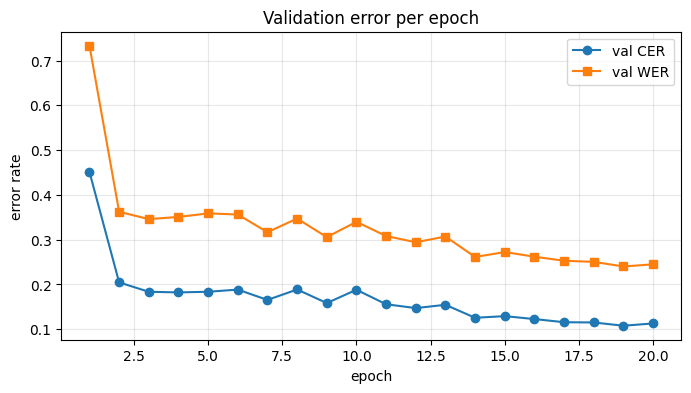

 epoch  eval_cer  eval_wer
   1.0  0.451274  0.733131
   2.0  0.204565  0.362310
   3.0  0.183673  0.345897
   4.0  0.182224  0.350760
   5.0  0.183673  0.358663
   6.0  0.188504  0.356231
   7.0  0.165439  0.316717
   8.0  0.188745  0.347112
   9.0  0.158435  0.305775
  10.0  0.188142  0.339818
  11.0  0.155778  0.308207
  12.0  0.147204  0.294225
  13.0  0.154571  0.306991
  14.0  0.125589  0.261398
  15.0  0.129211  0.272340
  16.0  0.122690  0.262006
  17.0  0.115687  0.252888
  18.0  0.115083  0.250456
  19.0  0.107837  0.240122
  20.0  0.112909  0.244985


In [13]:
hist = pd.DataFrame(trainer.state.log_history)
val_hist = hist[hist['eval_cer'].notna()][['epoch', 'eval_cer', 'eval_wer']] if 'eval_cer' in hist else pd.DataFrame()
if not val_hist.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(val_hist['epoch'], val_hist['eval_cer'], marker='o', label='val CER')
    plt.plot(val_hist['epoch'], val_hist['eval_wer'], marker='s', label='val WER')
    plt.xlabel('epoch'); plt.ylabel('error rate'); plt.title('Validation error per epoch')
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()
    print(val_hist.to_string(index=False))
else:
    print('No eval history found.')

# Save the best fine-tuned model

In [14]:
os.makedirs(BEST_MODEL_DIR, exist_ok=True)
trainer.save_model(BEST_MODEL_DIR)      # saves the restored best model
processor.save_pretrained(BEST_MODEL_DIR)
print('Saved best model + processor to', BEST_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model + processor to /content/drive/MyDrive/transcriptions_splits/trocr_best


# Final scoring on the TEST set

One pass over the held-out `test_set_line_crops/` pages with the best fine-tuned model.

In [15]:
def run_eval(df, mdl):
    ds = LineOCRDataset(df, processor, eval_transforms, MAX_TARGET_LENGTH)
    loader = DataLoader(ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=default_data_collator)
    mdl.eval()
    preds, refs = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(device)
            generated_ids = mdl.generate(pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS)
            preds.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
            labels = batch['labels'].clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs.extend(processor.batch_decode(labels, skip_special_tokens=True))
    cer = cer_metric.compute(predictions=preds, references=refs)
    wer = wer_metric.compute(predictions=preds, references=refs)
    return preds, refs, cer, wer

best_model = trainer.model.to(device)
all_preds, all_refs, final_cer, final_wer = run_eval(test_df, best_model)
print(f'Fine-tuned model on TEST — {len(all_refs)} lines')
print(f'  CER: {final_cer:.4f}')
print(f'  WER: {final_wer:.4f}')

print('\nSample TEST predictions:')
for pred, ref in list(zip(all_preds, all_refs))[:10]:
    print(f'  GT  : {ref}')
    print(f'  PRED: {pred}\n')

Fine-tuned model on TEST — 189 lines
  CER: 0.1411
  WER: 0.2913

Sample TEST predictions:
  GT  : 103
  PRED: 103

  GT  : pity that they were not capable enough
  PRED: a pretty that they were not capable enough

  GT  : of giving good scientific descriptions & accu-
  PRED: of giving good scientific descriptions & about

  GT  : rate drawings of the many curious Animals
  PRED: be drawings of the many curious Animals.

  GT  : they had opportunitys to see on their
  PRED: they had opportunity to see on their

  GT  : Voyages.
  PRED: Voyage

  GT  : Sept. 3th Several Shoals of flying fish were
  PRED: Sept. 3.th Several Shoals of flying fish were

  GT  : seen & a Bonito (Scomber Pelamys) was caught
  PRED: even & a Bonito in Leander-Technology, was caught

  GT  : my Son finihed a drawing of it & we feasted
  PRED: my Son finished a drawing of it & we fasted

  GT  : upon the Fish, which in my opinion is
  PRED: upon the Fish, which in my opinion is



# Per-book CER / WER on the test set

In [16]:
rows = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    rows.append({'book': test_df['book'].iloc[i],
                 'cer': cer_metric.compute(predictions=[pred], references=[ref]),
                 'wer': wer_metric.compute(predictions=[pred], references=[ref])})
by_book = pd.DataFrame(rows).groupby('book').agg(lines=('cer', 'size'),
                                                 CER=('cer', 'mean'),
                                                 WER=('wer', 'mean')).round(4)
print('Per-book fine-tuned scores on TEST:')
print(by_book)
print(f'\nOverall TEST  — CER: {final_cer:.4f}  WER: {final_wer:.4f}  (n={len(all_refs)})')

Per-book fine-tuned scores on TEST:
      lines     CER     WER
book                       
B1       24  0.0978  0.2628
B2       30  0.0853  0.2278
B3       32  0.1828  0.3631
B4       28  0.1841  0.3442
B5       39  0.2532  0.4337
B6       36  0.1531  0.3342

Overall TEST  — CER: 0.1411  WER: 0.2913  (n=189)


# Visualise sample test predictions with scores

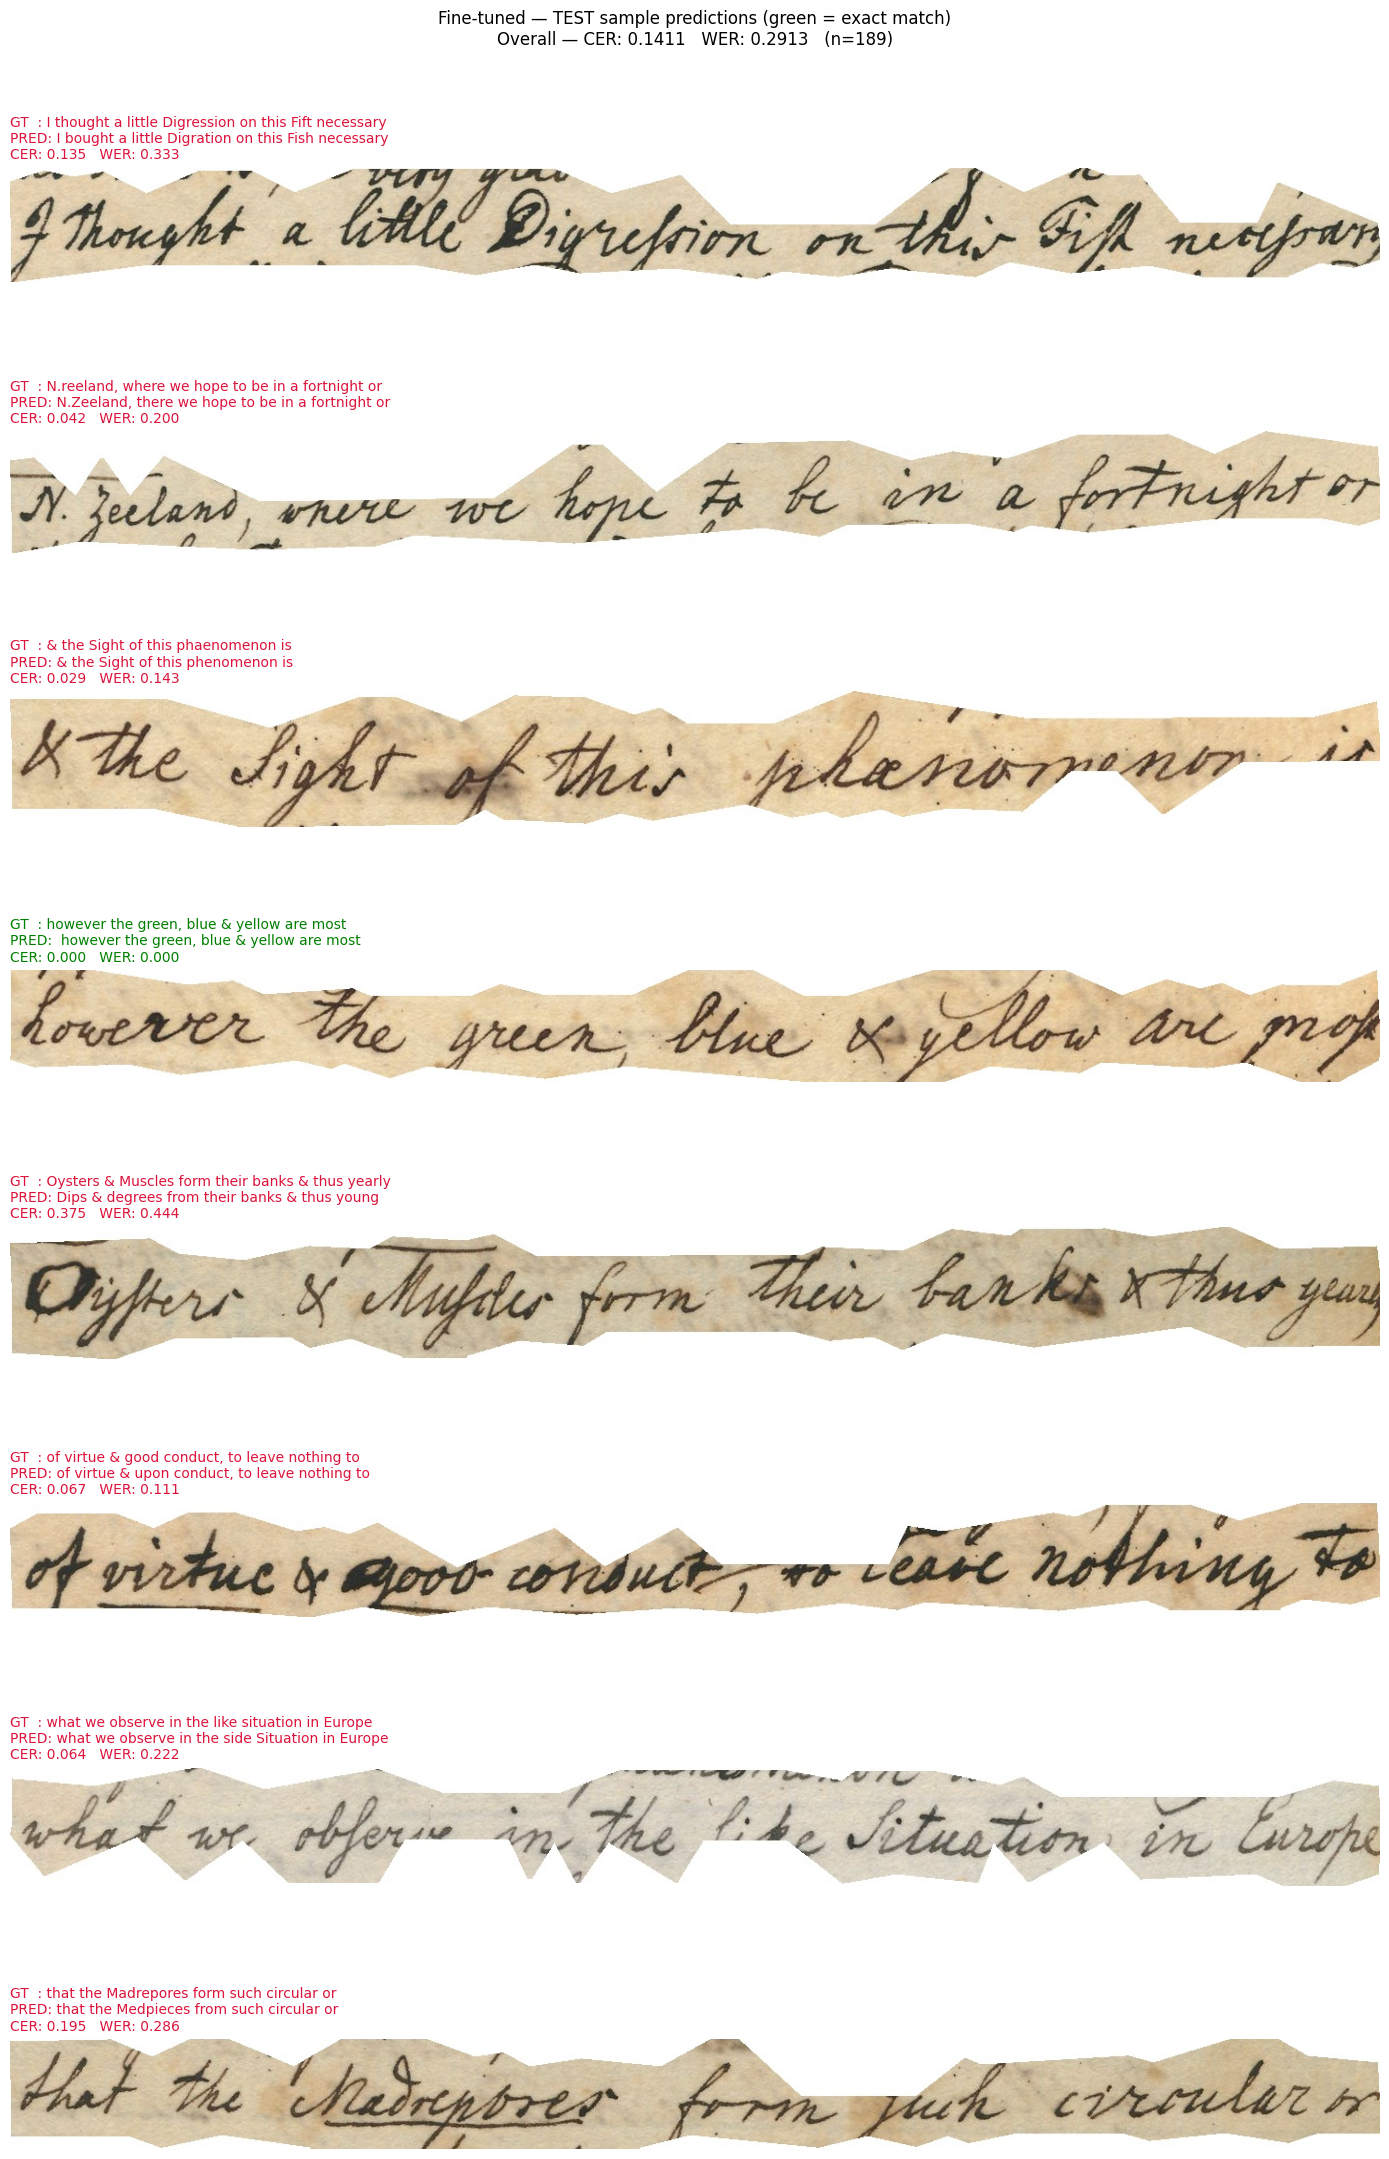

In [17]:
N_SHOW = 8
sample = test_df.sample(min(N_SHOW, len(test_df)), random_state=42).reset_index(drop=True)

best_model.eval()
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.8 * len(sample)))
if len(sample) == 1:
    axes = [axes]
with torch.no_grad():
    for ax, row in zip(axes, sample.itertuples()):
        image = Image.open(row.file_name).convert('RGB')
        pixel_values = processor(eval_transforms(image), return_tensors='pt').pixel_values.to(device)
        generated_ids = best_model.generate(pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS)
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        line_cer = cer_metric.compute(predictions=[pred], references=[row.text])
        line_wer = wer_metric.compute(predictions=[pred], references=[row.text])
        match = pred.strip() == row.text.strip()
        ax.imshow(image, cmap='gray')
        ax.set_title(f'GT  : {row.text}\nPRED: {pred}\nCER: {line_cer:.3f}   WER: {line_wer:.3f}',
                     fontsize=10, loc='left', color='green' if match else 'crimson')
        ax.axis('off')
plt.suptitle(f'Fine-tuned — TEST sample predictions (green = exact match)\n'
             f'Overall — CER: {final_cer:.4f}   WER: {final_wer:.4f}   (n={len(all_refs)})', y=1.0)
plt.tight_layout()
plt.show()

# 10 worst test predictions by CER

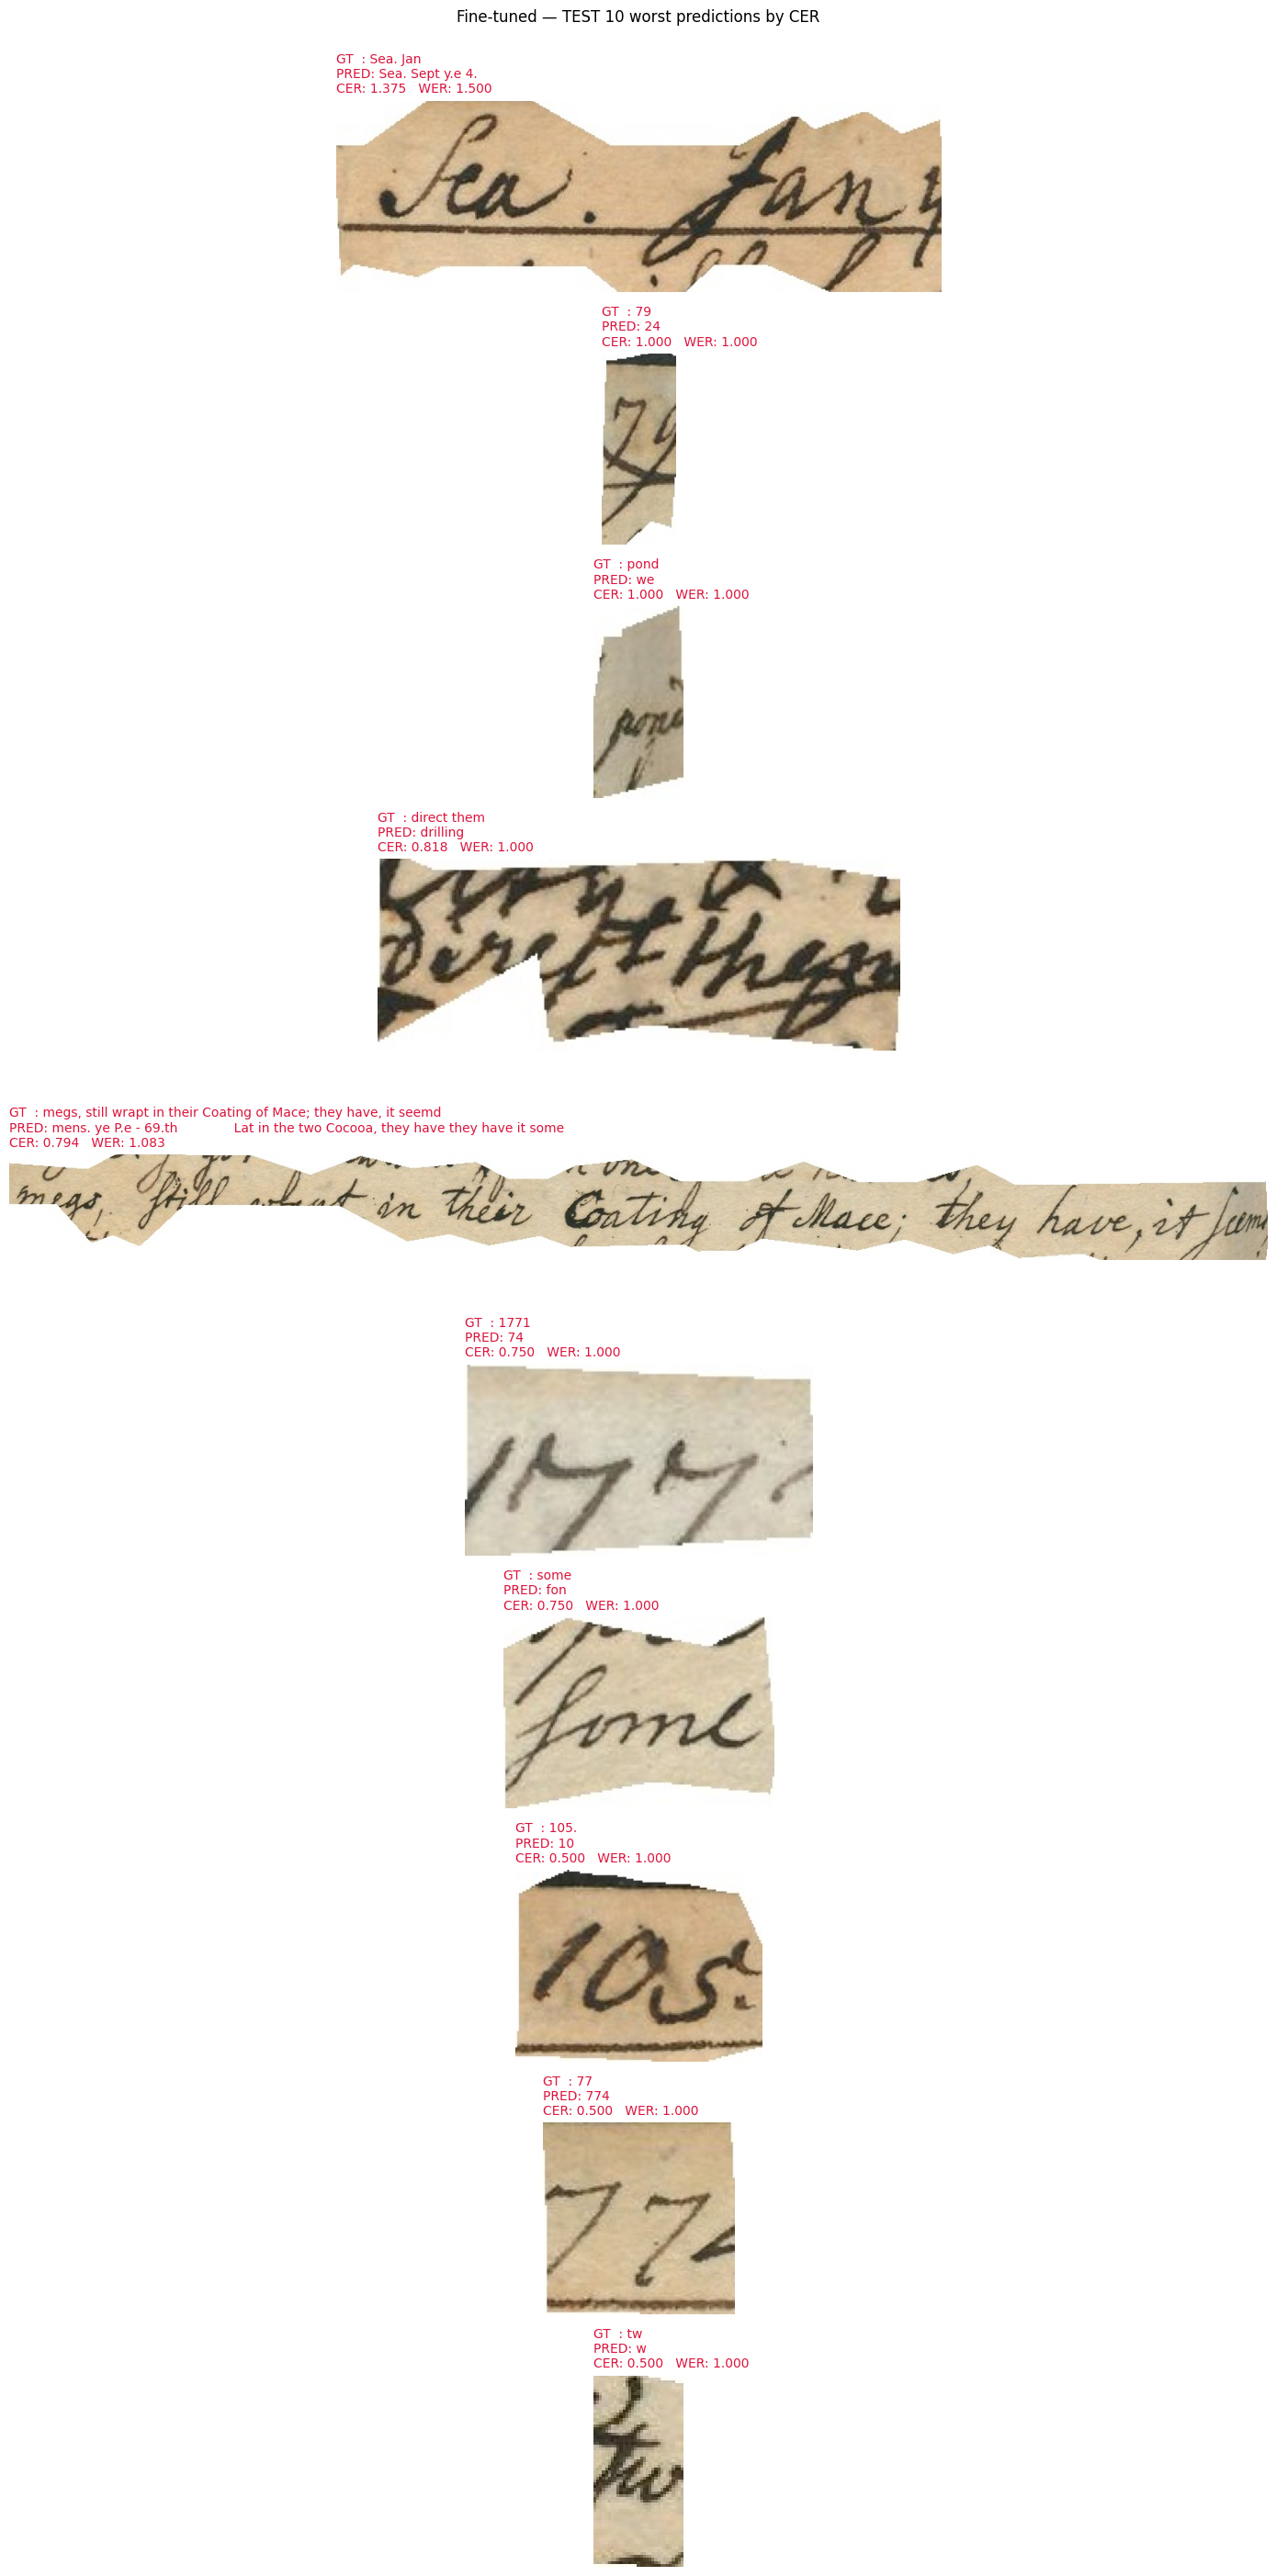

In [18]:
per_line = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    per_line.append({'cer': cer_metric.compute(predictions=[pred], references=[ref]),
                     'wer': wer_metric.compute(predictions=[pred], references=[ref]),
                     'file_name': test_df['file_name'].iloc[i], 'gt': ref, 'pred': pred})
worst = sorted(per_line, key=lambda r: (r['cer'], r['wer']), reverse=True)[:10]

fig, axes = plt.subplots(len(worst), 1, figsize=(14, 2.8 * len(worst)))
if len(worst) == 1:
    axes = [axes]
for ax, r in zip(axes, worst):
    ax.imshow(Image.open(r['file_name']).convert('RGB'), cmap='gray')
    ax.set_title(f"GT  : {r['gt']}\nPRED: {r['pred']}\nCER: {r['cer']:.3f}   WER: {r['wer']:.3f}",
                 fontsize=10, loc='left', color='crimson')
    ax.axis('off')
plt.suptitle('Fine-tuned — TEST 10 worst predictions by CER', y=1.0)
plt.tight_layout()
plt.show()

# Emit results for cross-experiment comparison

Prints a compact JSON block (test CER/WER, per-book scores, training history) to this cell's
**output**, wrapped in `RESULT_JSON_BEGIN` / `RESULT_JSON_END` markers. The comparison notebook
(`compareExperimentResults.ipynb`) reads this `.ipynb` file directly and parses the block — no
JSON files on Drive are involved. Just re-download / commit this notebook after running it.

In [19]:
# Emit results for the comparison notebook to read straight from THIS notebook's output.
# No Drive round-trip: compareExperimentResults.ipynb parses the printed block below.
import json
result = {
    'experiment': 'finetune_base',
    'label': 'Fine-tuned (base TrOCR)',
    'model': BASE_MODEL,
    'test': {'cer': float(final_cer), 'wer': float(final_wer), 'n': int(len(all_refs))},
    'per_book': by_book.reset_index().rename(columns={'CER':'cer','WER':'wer'}).to_dict('records'),
    'best_val_cer': (float(trainer.state.best_metric) if trainer.state.best_metric is not None else None),
    'history': [ {k: e[k] for k in ('epoch','loss','eval_loss','eval_cer','eval_wer') if k in e}
                 for e in trainer.state.log_history
                 if any(k in e for k in ('loss','eval_cer')) ],
}
print('RESULT_JSON_BEGIN')
print(json.dumps(result, indent=2))
print('RESULT_JSON_END')


RESULT_JSON_BEGIN
{
  "experiment": "finetune_base",
  "label": "Fine-tuned (base TrOCR)",
  "model": "microsoft/trocr-base-handwritten",
  "test": {
    "cer": 0.14109825166215217,
    "wer": 0.29129886506935687,
    "n": 189
  },
  "per_book": [
    {
      "book": "B1",
      "lines": 24,
      "cer": 0.0978,
      "wer": 0.2628
    },
    {
      "book": "B2",
      "lines": 30,
      "cer": 0.0853,
      "wer": 0.2278
    },
    {
      "book": "B3",
      "lines": 32,
      "cer": 0.1828,
      "wer": 0.3631
    },
    {
      "book": "B4",
      "lines": 28,
      "cer": 0.1841,
      "wer": 0.3442
    },
    {
      "book": "B5",
      "lines": 39,
      "cer": 0.2532,
      "wer": 0.4337
    },
    {
      "book": "B6",
      "lines": 36,
      "cer": 0.1531,
      "wer": 0.3342
    }
  ],
  "best_val_cer": 0.10783721772732761,
  "history": [
    {
      "epoch": 0.5494505494505495,
      "loss": 3.933136291503906
    },
    {
      "epoch": 1.0,
      "eval_loss": 3.385956525